In [1]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from scdepth import pl, fn, fit
from scipy import stats
import glob
from collections import Counter

In [2]:
cdf = pd.read_csv('../data/cohort.csv')
adf = pd.read_csv('../data/cohort_annotations.csv')
tmap = {(c.group, c.subgroup):c for c in cdf.itertuples()}
cdf = cdf[cdf['group'].str.contains('visium') | cdf['group'].str.contains('PBMC')].copy()
adf = adf[adf['group'].str.contains('visium') | adf['group'].str.contains('PBMC')].copy()

In [3]:
import os
summaries = []
lsummaries = []
samples = set()
for i, c in cdf.iterrows():
    f = f'../{c["dataset"]}/{c["sample"]}/scdepth_preseq_pilot_summary.txt'
    if not os.path.isfile(f):
        continue
    df = pd.read_csv(f, sep='\t')
    if 'saturation' not in df.columns:
        sdf = pd.read_csv(f'../{c["dataset"]}/{c["sample"]}/scdepth_limit_pilot_summary.txt', sep='\t')
        df = df.merge(sdf[['curve','unit_limit','saturation']], left_on=['curve', 'unit_limit'], right_on=['curve', 'unit_limit'])
    summaries.append((c, df))

In [4]:
summaries[0][-1].columns

Index(['sample', 'curve', 'unit_limit', 'limit', 'nb_lib_mae', 'preseq_mae',
       'nb_lib_L', 'preseq_L', 'preseq_L_defect', 'saturation'],
      dtype='object')

1000000 0.1495082229522637 1.4247073883773569
2000000 0.2947566707694022 2.816491272036103
5000000 0.734390256246428 6.7852869877228414
10000000 1.4665270460028097 12.860909381342594
20000000 2.884905407956708 23.23357586906215
50000000 6.942786431474673 44.69188221103628


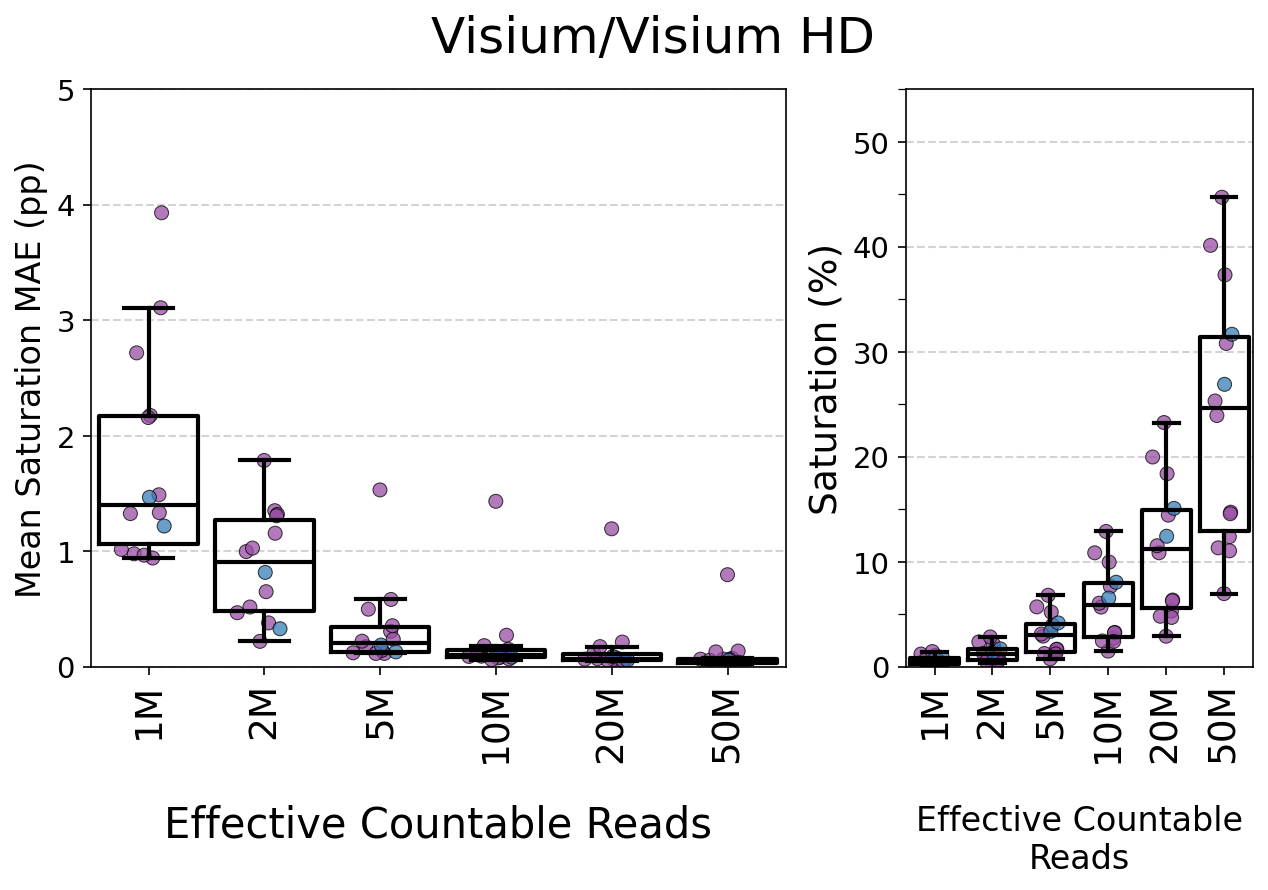

In [5]:
from collections import Counter
fig, (ax, sax) = pl.figax(1, 2, w=5, h=5, width_ratios=[2,1])
fig.subplots_adjust(hspace=0.2, wspace=0.23)
max_sat = 25
seen = set()


lboxes = {}
pboxes = {}
pfracs = {}

lcolors = {}
pcolors = {}
limits = {}
saturations = {}

for (c, df) in summaries:
    if 'visium' not in c['group']:
        continue

    d = df[df['unit_limit'] <= 50000000].copy()

    g = (
        d.groupby('unit_limit')
         .agg(
             unit_limit = ('unit_limit', 'first'),
             limit = ('limit', 'first'),
             saturation = ('saturation', 'first'),
             
             nb_lib_mae_mean = ('nb_lib_mae', 'mean'),
             nb_lib_mae_frac = ('nb_lib_mae', lambda x: x.isna().mean()),
             preseq_mae_mean = ('preseq_mae', 'mean'),
             preseq_mae_frac = ('preseq_mae', lambda x: x.isna().mean())
         )
    )


    cc = adf[(adf['group'] == c['group']) & (adf['subgroup'] == c['subgroup'])].iloc[0]

    #print(cc['group'], cc['subgroup'])
    for i, t in enumerate(g.itertuples()):
        limits[i] = t.Index
        lboxes.setdefault(i, []).append(min(10, t.nb_lib_mae_mean))
        lcolors.setdefault(i, []).append(cc.group_color)
        saturations.setdefault(i, []).append(t.saturation)
        
        pboxes.setdefault(i, []).append(min(10, t.preseq_mae_mean))
        pcolors.setdefault(i, []).append(cc.group_color)
        pfracs.setdefault(i, []).append(t.preseq_mae_frac)

        

xt = []
xl = []
lim_labels = ['1M', '2M', '5M', '10M', '20M', '50M', '100M', '200M', '500M']

for k, l in sorted(limits.items()):
    #print(k, 
    pl.jitter_box(ax, k, lboxes[k], color=lcolors[k], s=45, edgecolor='k', lw=0.5, bwidth=0.85, alpha=0.75,
                 blw=2, mlw=2, wlw=2, plw=2)
    xt.append(k)
    xl.append(f'{lim_labels[k]}')


    sel = np.isfinite(pboxes[k])
    
    print(l, min(saturations[k]), max(saturations[k]))
    pl.jitter_box(sax, k, np.array(saturations[k])[sel], color=np.array(pcolors[k])[sel], s=45, edgecolor='k', lw=0.5, bwidth=0.85, alpha=0.75,
                 blw=2, mlw=2, wlw=2, plw=2)

ax.set_ylim(0, 5)
sax.set_ylim(0, 55)
sax.set_yticks(np.arange(0, 56, 10))
sax.set_yticks(np.arange(0, 56, 5), minor=True)

for a in (ax, sax):
    #a.set_xlim(5, 70)
    #a.set_xticks(np.arange(10, 75, 10))
   
    #a.set_ylim(0, 5.1)
    a.tick_params(axis='both', which='both', length=4)
    a.tick_params(axis='both', which='major', labelsize=14)
    
    a.set_xticks(xt)
    
    a.grid(axis='y', color='lightgray', ls='--', lw=1, which='major')
    a.set_axisbelow(True)

ax.set_xticklabels(xl, rotation=90, fontsize=18)
sax.set_xticklabels(xl, rotation=90, fontsize=18)


ax.set_xlabel('Effective Countable Reads', fontsize=20, labelpad=20)

ax.set_ylabel('Mean\nSaturation MAE (pp)', fontsize=18)
sax.set_ylabel('Saturation (%)', fontsize=18)
sax.set_xlabel('Effective Countable\nReads', fontsize=16, labelpad=20)


ax.set_ylabel('Mean Saturation MAE (pp)', fontsize=16)

fig.suptitle('Visium/Visium HD', fontsize=24)
fig.savefig('../Figures/Figure 1F Minimum Visium.svg', bbox_inches='tight')

100 0.3993746574542456 0.9498927625215572
200 0.8015854401650131 1.8997850013765856
500 1.96258155925274 4.597494644363678
1000 3.872101565084762 8.828181155561424
2000 7.49473792387046 16.44429289725595
5000 17.12325886745198 33.63506665327755
10000 29.76686772744516 51.64207917905201


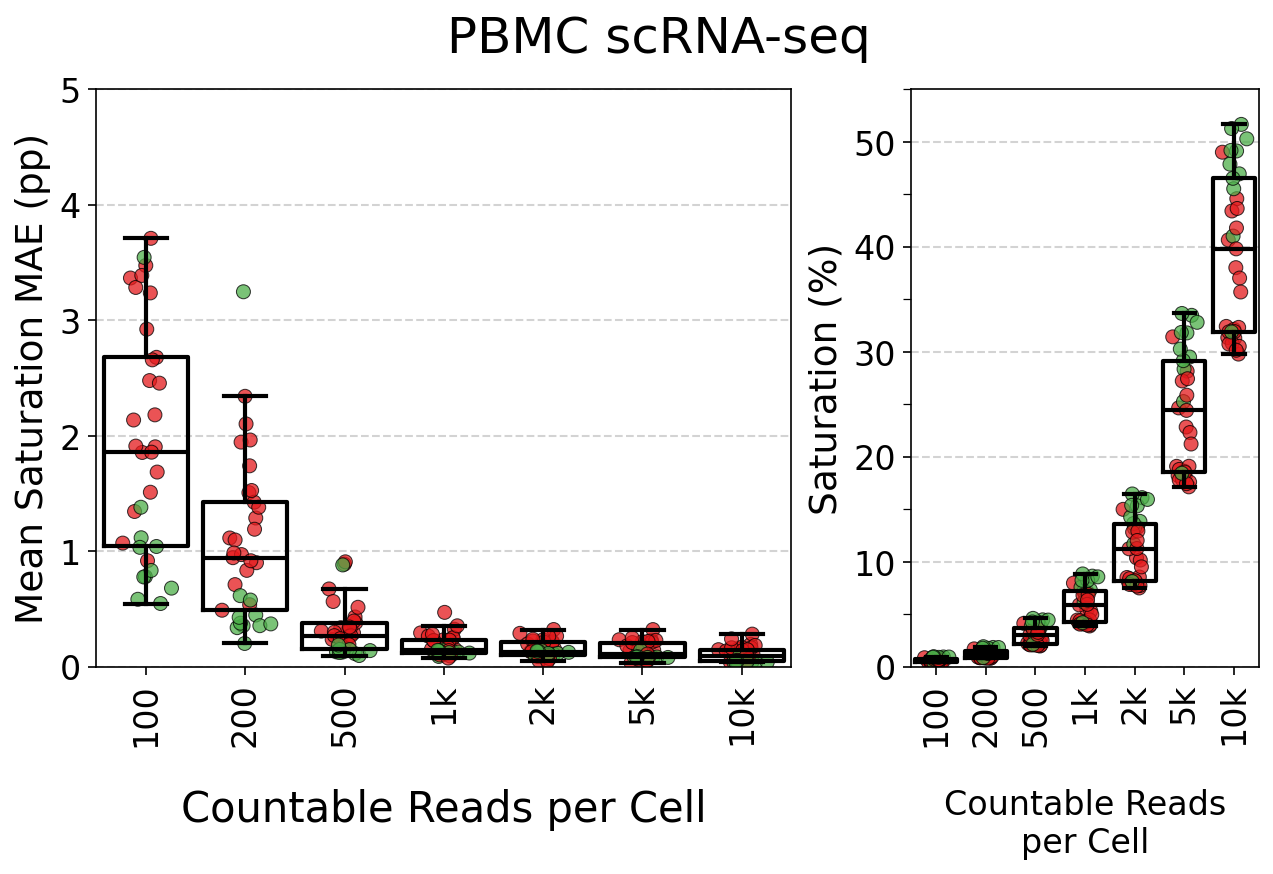

In [6]:
fig, (ax, sax) = pl.figax(1, 2, w=5, h=5, width_ratios=[2,1])
fig.subplots_adjust(hspace=0.2, wspace=0.23)
max_sat = 25
seen = set()


lboxes = {}
pboxes = {}
pfracs = {}

lcolors = {}
pcolors = {}
limits = {}

saturations = {}


for (c, df) in summaries:
    if 'visium'  in c['group']:
        continue
    d = df[df['unit_limit'] <= 10000].copy()
    g = (
        d.groupby('unit_limit')
         .agg(
             unit_limit = ('unit_limit', 'first'),
             limit = ('limit', 'first'),
             saturation = ('saturation', 'first'),
             
             nb_lib_mae_mean = ('nb_lib_mae', 'mean'),
             nb_lib_mae_frac = ('nb_lib_mae', lambda x: x.isna().mean()),
             preseq_mae_mean = ('preseq_mae', 'mean'),
             preseq_mae_frac = ('preseq_mae', lambda x: x.isna().mean())
         )
    )


    cc = adf[(adf['group'] == c['group']) & (adf['subgroup'] == c['subgroup'])].iloc[0]

    #print(cc['group'], cc['subgroup'])
    for i, t in enumerate(g.itertuples()):
        limits[i] = t.Index
        lboxes.setdefault(i, []).append(min(10, t.nb_lib_mae_mean))
        lcolors.setdefault(i, []).append(cc.group_color)
        saturations.setdefault(i, []).append(t.saturation)
        
        pboxes.setdefault(i, []).append(min(10, t.preseq_mae_mean))
        pcolors.setdefault(i, []).append(cc.group_color)
        pfracs.setdefault(i, []).append(t.preseq_mae_frac)


        

xt = []
xl = []

lim_labels = ['100','200','500','1k','2k', '5k', '10k', '20k', '50k', '100k']
for k, l in sorted(limits.items()):
    pl.jitter_box(ax, k, lboxes[k], color=lcolors[k], s=45, edgecolor='k', lw=0.5, bwidth=0.85, alpha=0.75,
                 blw=2, mlw=2, wlw=2, plw=2)
    xt.append(k)
    xl.append(f'{lim_labels[k]}')
    
    sel = np.isfinite(pboxes[k])
    print(l, min(saturations[k]), max(saturations[k]))
    pl.jitter_box(sax, k, np.array(saturations[k])[sel], color=np.array(pcolors[k])[sel], s=45, edgecolor='k', lw=0.5, bwidth=0.85, alpha=0.75,
                 blw=2, mlw=2, wlw=2, plw=2)
    

ax.set_ylim(0, 5)
sax.set_ylim(0, 55)
sax.set_yticks(np.arange(0, 56, 10))
sax.set_yticks(np.arange(0, 56, 5), minor=True)
    

ax.set_xticklabels(xl, rotation=90, fontsize=18)
sax.set_xticklabels(xl, rotation=90, fontsize=18)

ax.set_xlabel('Countable Reads per Cell', fontsize=20, labelpad=20)
sax.set_ylabel('Saturation (%)', fontsize=18)
sax.set_xlabel('Countable Reads\nper Cell', fontsize=16, labelpad=20)
ax.set_ylabel('Mean Saturation MAE (pp)', fontsize=18)


for a in (ax, sax):
    a.tick_params(axis='both', which='both', length=4)
    a.tick_params(axis='both', which='both', labelsize=16)
    a.set_xticks(xt)
    
    a.grid(axis='y', color='lightgray', ls='--', lw=1, which='major')
    a.set_axisbelow(True)
fig.suptitle('PBMC scRNA-seq', fontsize=24)
   
fig.savefig('../Figures/Figure 1G Minimum PBMC.svg', bbox_inches='tight')

In [7]:
df = pd.read_csv('../Figures/Table S1.csv')
df['align_rate'] = 100 * df['countable_reads'] / df['total_reads'] 

In [8]:
for g, d in df.groupby('dataset'):
    #display(d)
    print(f"{g} {d['align_rate'].min():.2f} - {d['align_rate'].max():.2f}")

scrna 47.99 - 80.38
scrna_expanded 41.39 - 81.46
scrna_flex 64.59 - 97.18
visium 95.38 - 96.69
visium_hd 77.91 - 94.65
